# Threshold calibration — delegation clustering + model routing

**Issue:** [#140](https://github.com/frederick-douglas-pearce/agentfluent/issues/140)

Both `agentfluent.diagnostics.delegation` (#110) and
`agentfluent.diagnostics.model_routing` (#111) shipped with threshold
constants informed by backlog guidance, not empirical data. This
notebook validates those defaults against real agent session data
from `~/.claude/projects/`.

## ⚠️ Limitations

- **Single-developer dataset.** The calibration here is based on one
  contributor's session history. Real-world usage patterns across
  different domains (web dev, data science, infrastructure work)
  could easily justify different thresholds. Treat these as informed
  starting points, not settled defaults. Re-run this notebook when
  contributors with representative data can add projects.
- **One run per moment in time.** Thresholds don't need weekly
  re-tuning. Re-run when: (a) feature code changes that affect
  threshold semantics, (b) new contributors add project data, or
  (c) observed false-positive / false-negative rates climb.

## Coverage

15 thresholds across both modules:

**Delegation** — `MIN_TEXT_TOKENS`, `LSA_COMPONENTS`,
`DEFAULT_MIN_CLUSTER_SIZE`, `DEFAULT_MIN_SIMILARITY`,
`_SILHOUETTE_K_MAX`, `_CONFIDENCE_HIGH_SIZE`,
`_CONFIDENCE_HIGH_COHESION`, `_CONFIDENCE_MEDIUM_COHESION`,
`_HEAVY_TOKEN_THRESHOLD`

**Model routing** — `_MIN_INVOCATIONS_FOR_ANALYSIS`,
`_SIMPLE_MAX_TOOL_CALLS`, `_SIMPLE_MAX_TOKENS`,
`_COMPLEX_MIN_TOOL_CALLS`, `_COMPLEX_MIN_TOKENS`,
`_COMPLEX_MIN_ERROR_RATE`

## Setup

Point this at any Claude Code config directory. Defaults to
``~/.claude/`` (the standard location) if the ``CLAUDE_CONFIG_DIR``
environment variable isn't set. To analyze a different dataset
(e.g., a colleague's shared projects), either edit the ``config_dir``
value in the cell below or export the env var before launching
Jupyter::

    export CLAUDE_CONFIG_DIR=/path/to/other/.claude
    uv run jupyter lab scripts/calibration/threshold_validation.ipynb


In [1]:
from __future__ import annotations

import os
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from agentfluent.analytics.pipeline import analyze_sessions
from agentfluent.core.discovery import discover_projects
from agentfluent.core.paths import projects_dir_for
from agentfluent.diagnostics.delegation import (
    MIN_TEXT_TOKENS,
    cluster_delegations,
)
from agentfluent.diagnostics.model_routing import (
    classify_complexity,
    aggregate_agent_stats,
)
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
pd.options.display.max_rows = 20
pd.options.display.float_format = "{:.2f}".format

# Override via CLAUDE_CONFIG_DIR env var, or edit this line directly.
# `None` => default `~/.claude/` location.
config_dir: Path | None = (
    Path(os.environ["CLAUDE_CONFIG_DIR"])
    if "CLAUDE_CONFIG_DIR" in os.environ
    else None
)
# `projects_dir_for(None)` returns None; `discover_projects(base_path=None)`
# then falls back to the default `~/.claude/projects/` location.
projects_root = projects_dir_for(config_dir)
from agentfluent.core.discovery import DEFAULT_PROJECTS_DIR
effective_root = projects_root if projects_root is not None else DEFAULT_PROJECTS_DIR
print(f"Analyzing projects under: {effective_root}")

Analyzing projects under: /home/fdpearce/.claude/projects


## Load all sessions

In [2]:
projects = list(discover_projects(base_path=projects_root))
print(f"Projects: {len(projects)}")

all_invocations = []
for p in projects:
    paths = [s.path for s in p.sessions]
    result = analyze_sessions(paths)
    for s in result.sessions:
        all_invocations.extend(s.invocations)

print(f"Total invocations: {len(all_invocations)}")

Projects: 7


Malformed JSON at a0e5f523-1191-45ca-97ba-3b40c64f57c0.jsonl:662


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:129


Malformed JSON at 14ddceb0-4c3b-4194-be1c-060c019303cd.jsonl:228


Total invocations: 255


In [3]:
df_inv = pd.DataFrame([
    {
        "agent_type": inv.agent_type,
        "total_tokens": inv.total_tokens,
        "tool_uses": inv.tool_uses,
        "duration_ms": inv.duration_ms,
        "has_trace": inv.trace is not None,
        "trace_model": inv.trace.model if inv.trace is not None else None,
        "description_tokens": len(inv.description.split()),
        "prompt_tokens": len(inv.prompt.split()),
        "combined_tokens": len((inv.description + " " + inv.prompt).split()),
    }
    for inv in all_invocations
])
df_inv.describe()

,total_tokens,tool_uses,duration_ms,description_tokens,prompt_tokens,combined_tokens
count,211.00,211.00,211.00,255.00,255.00,255.00
mean,47049.07,16.64,227736.46,4.20,380.62,384.83
std,20656.12,15.20,858300.80,1.21,311.41,311.62
min,14879.00,0.00,3709.00,2.00,21.00,26.00
25%,32497.50,6.00,34158.00,3.00,156.00,160.50
50%,42395.00,13.00,64463.00,4.00,307.00,311.00
75%,56146.00,23.50,149682.00,5.00,505.00,510.00
max,141408.00,97.00,9028080.00,9.00,2468.00,2472.00


## Per-agent-type distribution

How much data do we have for each agent type? Agent types with very
few invocations are skipped entirely by model-routing
(`_MIN_INVOCATIONS_FOR_ANALYSIS`) and can't form clusters under
`DEFAULT_MIN_CLUSTER_SIZE`.

agent_type
Explore              100
general-purpose       44
pm                    33
unknown               32
architect             19
Plan                  17
claude-code-guide     10
Name: count, dtype: int64


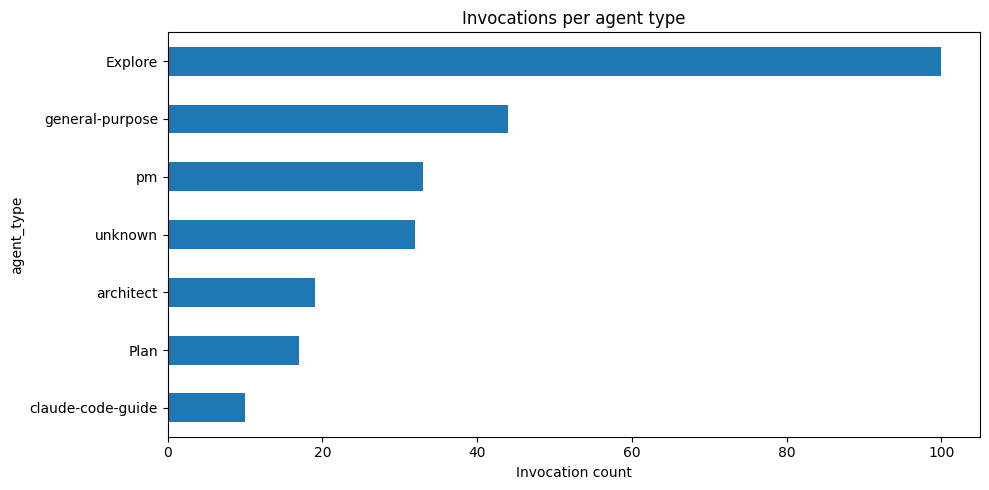

In [4]:
agent_counts = df_inv["agent_type"].value_counts()
print(agent_counts)

fig, ax = plt.subplots()
agent_counts.plot.barh(ax=ax)
ax.set_xlabel("Invocation count")
ax.set_title("Invocations per agent type")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 1 · `MIN_TEXT_TOKENS` — text-length filter for clustering

Default: **50 tokens** (combined `description + prompt`).

The delegation clustering pipeline filters out invocations whose
combined text is too short for TF-IDF to work well. Because agent-
to-agent delegations are generated by a parent agent (no human in
the loop), the pathological "help me" one-liners that would motivate
an aggressive anti-noise floor don't occur here — the realistic
floor is well above that, and the filter acts as a guard against
truncated or malformed inputs rather than against short human
phrasing. Observed combined lengths on this dataset start ~100
tokens, so `50` leaves a safe margin without cutting into the real
distribution.

general-purpose invocations: 44


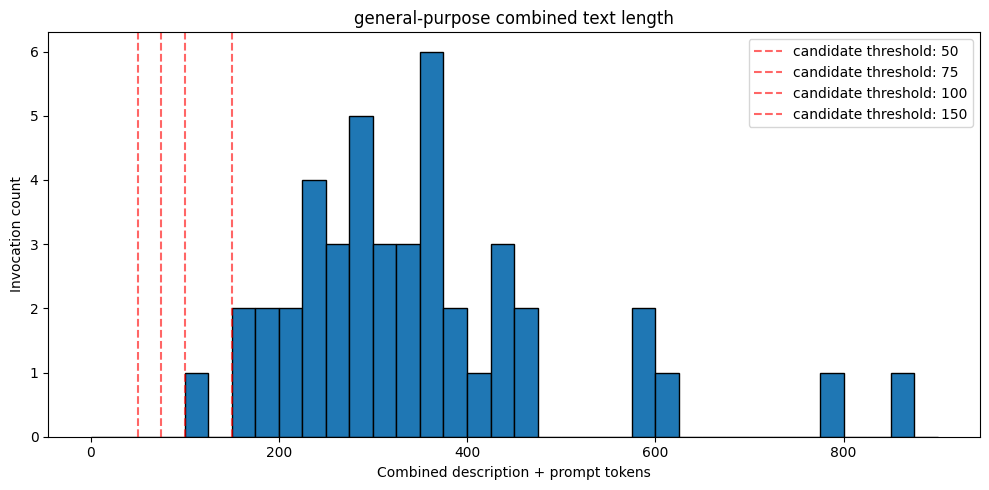

  threshold= 20: keeps   44 / 44 (100.0%)
  threshold= 30: keeps   44 / 44 (100.0%)
  threshold= 50: keeps   44 / 44 (100.0%)
  threshold= 75: keeps   44 / 44 (100.0%)
  threshold=100: keeps   44 / 44 (100.0%)
  threshold=150: keeps   43 / 44 ( 97.7%)


In [5]:
gp = df_inv[df_inv["agent_type"].str.lower() == "general-purpose"]
print(f"general-purpose invocations: {len(gp)}")

fig, ax = plt.subplots()
bins = np.arange(0, gp["combined_tokens"].max() + 50, 25)
ax.hist(gp["combined_tokens"], bins=bins, edgecolor="black")
for t in [50, 75, 100, 150]:
    ax.axvline(t, color="red", linestyle="--", alpha=0.6,
               label=f"candidate threshold: {t}")
ax.set_xlabel("Combined description + prompt tokens")
ax.set_ylabel("Invocation count")
ax.set_title("general-purpose combined text length")
ax.legend()
plt.tight_layout()
plt.show()

# Agent-to-agent prompts don't go below meaningful-context length the
# way human prompts can, so the sweep starts at 20 (the prior default)
# and climbs through plausible "realistic floor" candidates.
for t in [20, 30, 50, 75, 100, 150]:
    kept = (gp["combined_tokens"] >= t).sum()
    pct = 100 * kept / len(gp) if len(gp) else 0
    print(f"  threshold={t:>3}: keeps {kept:>4} / {len(gp)} ({pct:5.1f}%)")

**Observation.** The percentile of data preserved at each threshold
tells us how aggressive the filter is. Because these are agent-to-
agent prompts, not human-typed ones, the low end of the distribution
doesn't carry the "I need to exclude 'help me' style noise" shape
you'd expect from an interactive tool — it's a guard against
truncated/malformed input, not against short human phrasing.

**Decision rule:** pick the largest value that still keeps ~100% of
realistic delegations. Observed data starts ~100 tokens, so anything
up to ~50 preserves the full corpus with margin; jumping to 75+ would
begin trimming the real distribution.

## 2 · `LSA_COMPONENTS` — TF-IDF dimensionality reduction

Default: **50 components**.

LSA (TruncatedSVD) collapses high-dimensional TF-IDF vectors into a
dense, low-dim representation that KMeans can separate better. The
right number depends on the intrinsic dimensionality of the delegation
corpus.

gp after MIN_TEXT_TOKENS=50: 44



n_components variance table:
  n_components=  5: 29.0%
  n_components= 10: 50.7%
  n_components= 15: 65.8%
  n_components= 20: 77.2%
  n_components= 25: 85.6%
  n_components= 30: 91.2% ←
  n_components= 35: 95.5% ←
  n_components= 40: 98.4% ←

Lowest n_components reaching 90% variance: 30 (91.2%)


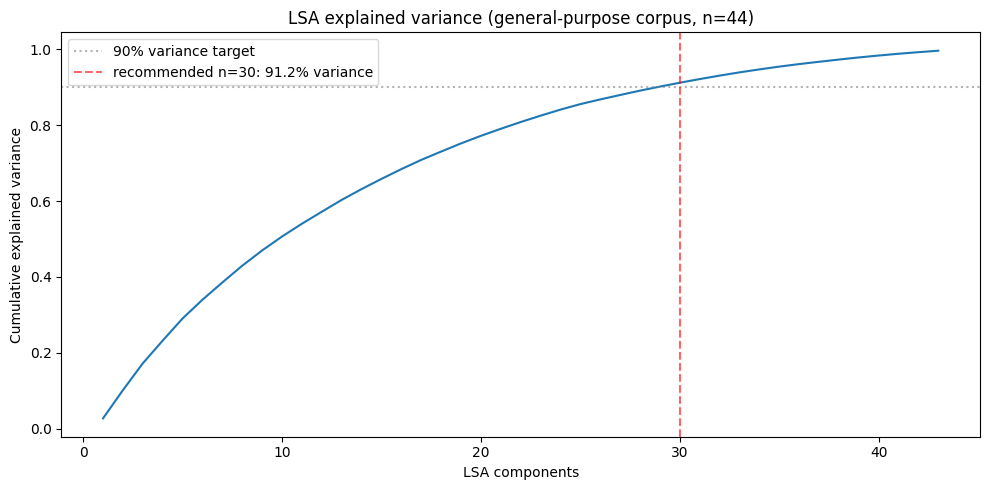

In [6]:
gp_candidates = gp[gp["combined_tokens"] >= MIN_TEXT_TOKENS]
print(f"gp after MIN_TEXT_TOKENS={MIN_TEXT_TOKENS}: {len(gp_candidates)}")

VARIANCE_TARGET = 0.90

if len(gp_candidates) >= 5:
    texts = [
        (inv.description + " " + inv.prompt)
        for inv in all_invocations
        if inv.agent_type.lower() == "general-purpose"
        and len((inv.description + " " + inv.prompt).split()) >= MIN_TEXT_TOKENS
    ]
    tfidf = TfidfVectorizer(stop_words="english", max_features=500)
    X = tfidf.fit_transform(texts)
    n_components = min(100, X.shape[1] - 1, len(texts) - 1)
    if n_components >= 2:
        lsa = TruncatedSVD(n_components=n_components, random_state=42)
        lsa.fit(X)
        explained = np.cumsum(lsa.explained_variance_ratio_)

        # Sweep in increments of 5 first, then pick the lowest n that
        # clears VARIANCE_TARGET. Reporting the table before the chart
        # lets the reader see where the elbow sits.
        sweep = list(range(5, len(explained) + 1, 5))
        print(f"\nn_components variance table:")
        for ncomp in sweep:
            marker = " ←" if explained[ncomp-1] >= VARIANCE_TARGET else ""
            print(f"  n_components={ncomp:>3}: {explained[ncomp-1]:.1%}{marker}")

        hitting = [n for n in sweep if explained[n-1] >= VARIANCE_TARGET]
        recommended = hitting[0] if hitting else None
        if recommended is not None:
            print(
                f"\nLowest n_components reaching {VARIANCE_TARGET:.0%} "
                f"variance: {recommended} "
                f"({explained[recommended-1]:.1%})"
            )
        else:
            print(
                f"\nNo swept value reaches {VARIANCE_TARGET:.0%} variance "
                f"on this dataset (max {explained[-1]:.1%} at "
                f"n={len(explained)})."
            )

        fig, ax = plt.subplots()
        ax.plot(range(1, len(explained) + 1), explained)
        ax.axhline(
            VARIANCE_TARGET, color="gray", linestyle=":", alpha=0.6,
            label=f"{VARIANCE_TARGET:.0%} variance target",
        )
        if recommended is not None:
            ax.axvline(
                recommended, color="red", linestyle="--", alpha=0.6,
                label=f"recommended n={recommended}: "
                      f"{explained[recommended-1]:.1%} variance",
            )
        ax.set_xlabel("LSA components")
        ax.set_ylabel("Cumulative explained variance")
        ax.set_title(f"LSA explained variance (general-purpose corpus, n={len(texts)})")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Not enough candidates for LSA analysis.")

**Decision rule:** pick the smallest number of components that
captures ≥ 90% of the variance (marked `←` in the table above and as
the red dashed line on the chart). Higher components beyond that add
noise and slow KMeans.

## 3 · `DEFAULT_MIN_CLUSTER_SIZE` — minimum cluster size

Default: **5 invocations**.

Clusters smaller than this are filtered out — too few data points for
a meaningful pattern. Too high: legitimate emerging patterns get
dropped. Too low: noise gets surfaced as recommendations.

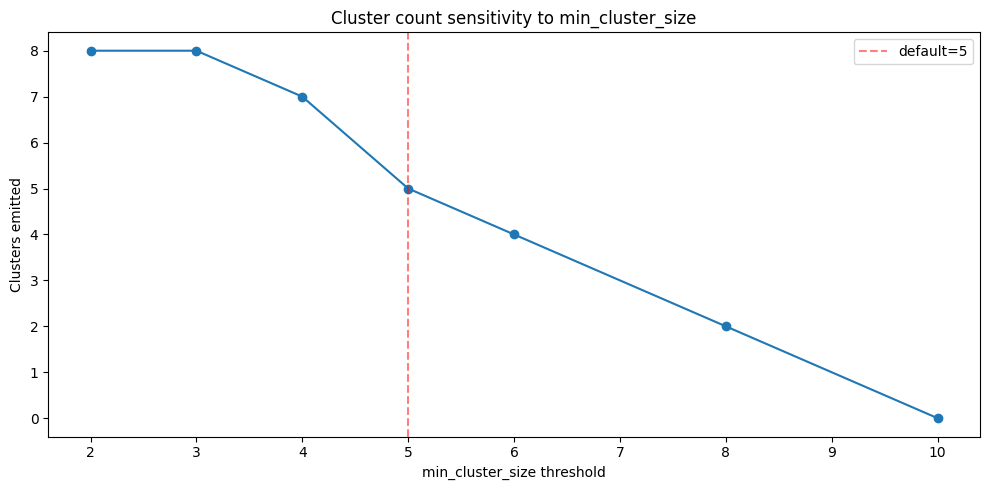

  min_cluster_size=2: 8 clusters emitted
  min_cluster_size=3: 8 clusters emitted
  min_cluster_size=4: 7 clusters emitted
  min_cluster_size=5: 5 clusters emitted
  min_cluster_size=6: 4 clusters emitted
  min_cluster_size=8: 2 clusters emitted
  min_cluster_size=10: 0 clusters emitted


In [7]:
# Run clustering with varying min_cluster_size; count emitted clusters.
invs_list = [
    inv for inv in all_invocations
    if inv.agent_type.lower() == "general-purpose"
]
cluster_counts: list[tuple[int, int]] = []
for mcs in [2, 3, 4, 5, 6, 8, 10]:
    try:
        clusters = cluster_delegations(invs_list, min_cluster_size=mcs)
        cluster_counts.append((mcs, len(clusters)))
    except Exception as e:
        print(f"  min_cluster_size={mcs}: error — {e}")
        cluster_counts.append((mcs, 0))

fig, ax = plt.subplots()
sizes, counts = zip(*cluster_counts)
ax.plot(sizes, counts, marker="o")
ax.set_xlabel("min_cluster_size threshold")
ax.set_ylabel("Clusters emitted")
ax.set_title("Cluster count sensitivity to min_cluster_size")
ax.axvline(5, color="red", linestyle="--", alpha=0.5, label="default=5")
ax.legend()
plt.tight_layout()
plt.show()

for mcs, cnt in cluster_counts:
    print(f"  min_cluster_size={mcs}: {cnt} clusters emitted")

**Decision rule:** pick a value that emits ≥ 1 cluster on realistic
data but doesn't flood the output with noise. Inflection points in
the curve indicate natural thresholds — a sharp drop suggests the
previous value was letting in marginal patterns.

## 4 · `DEFAULT_MIN_SIMILARITY` — dedup threshold

Default: **0.70** (cosine similarity).

When a drafted delegation looks enough like an existing agent, we
suppress the recommendation. Too high: we recommend agents that
already exist. Too low: we over-suppress.

Existing agents in configs: 2
  architect, pm


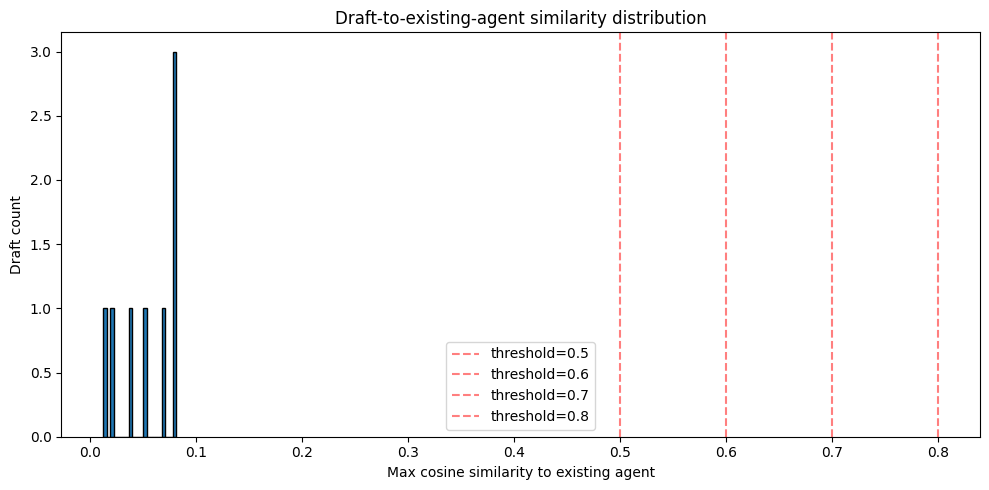

  threshold=0.3: dedup 0 / 8 drafts
  threshold=0.5: dedup 0 / 8 drafts
  threshold=0.7: dedup 0 / 8 drafts
  threshold=0.8: dedup 0 / 8 drafts


In [8]:
from agentfluent.config.scanner import scan_agents
from agentfluent.diagnostics.delegation import generate_draft
from sklearn.metrics.pairwise import cosine_similarity

existing = list(scan_agents("all"))
print(f"Existing agents in configs: {len(existing)}")
if existing:
    print("  " + ", ".join(sorted(c.name for c in existing)))

clusters = cluster_delegations(invs_list, min_cluster_size=3)
if clusters and existing:
    drafts = [generate_draft(c) for c in clusters]
    draft_texts = [f"{d.description} {d.prompt_template}" for d in drafts]
    config_texts = [c.description or c.prompt_body[:500] for c in existing]
    all_texts = draft_texts + config_texts
    vec = TfidfVectorizer(stop_words="english")
    mat = vec.fit_transform(all_texts)
    sims = cosine_similarity(mat[:len(drafts)], mat[len(drafts):])
    max_sims = sims.max(axis=1)

    fig, ax = plt.subplots()
    ax.hist(max_sims, bins=20, edgecolor="black")
    for t in [0.5, 0.6, 0.7, 0.8]:
        ax.axvline(t, color="red", linestyle="--", alpha=0.5,
                   label=f"threshold={t}")
    ax.set_xlabel("Max cosine similarity to existing agent")
    ax.set_ylabel("Draft count")
    ax.set_title("Draft-to-existing-agent similarity distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    for t in [0.3, 0.5, 0.7, 0.8]:
        deduped = (max_sims > t).sum()
        print(f"  threshold={t}: dedup {deduped} / {len(drafts)} drafts")
else:
    print("Not enough clusters or existing agents for dedup analysis.")

## 5 · `_SILHOUETTE_K_MAX` — upper bound on silhouette-selected k

Default: **10**.

For small n, we force k=2. For larger n, we sweep k in
`[2, min(10, n // 5)]` and pick the best-silhouette. The upper bound
matters only when n > 50 — below that, `n // 5` dominates.

In [9]:
# For the general-purpose corpus, how high would k realistically go?
n_gp = len([i for i in all_invocations if i.agent_type.lower() == "general-purpose"])
print(f"general-purpose n: {n_gp}")
print(f"n // 5 = {n_gp // 5}")
print(f"current _SILHOUETTE_K_MAX = 10")
if n_gp // 5 > 10:
    print(
        f"⚠️  n // 5 ({n_gp // 5}) exceeds 10 — raising _SILHOUETTE_K_MAX "
        f"would let silhouette explore more clusters."
    )
else:
    print(
        "✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX "
        "has no effect on this dataset."
    )

general-purpose n: 44
n // 5 = 8
current _SILHOUETTE_K_MAX = 10
✓ n // 5 is within the current cap; raising _SILHOUETTE_K_MAX has no effect on this dataset.


## 6 · Confidence tier boundaries

Defaults:
- `_CONFIDENCE_HIGH_SIZE = 10`, `_CONFIDENCE_HIGH_COHESION = 0.8`
- `_CONFIDENCE_MEDIUM_COHESION = 0.6`
- Otherwise → low

**Terminology.** *Cohesion* here is a cluster-level aggregate —
specifically the mean pairwise cosine similarity among the cluster's
TF-IDF-embedded members (`_mean_pairwise_cosine` in
`delegation.py`). That makes it distinct from the `0.70` threshold in
§4, which is a raw pairwise cosine between a single draft and a
single existing agent. Both axes use cosine similarity under the
hood; cohesion additionally averages over all member pairs in one
cluster.

       size  cohesion
count  8.00      8.00
mean   5.50      0.42
std    1.85      0.17
min    3.00      0.19
25%    4.00      0.34
50%    5.50      0.41
75%    6.50      0.44
max    8.00      0.79


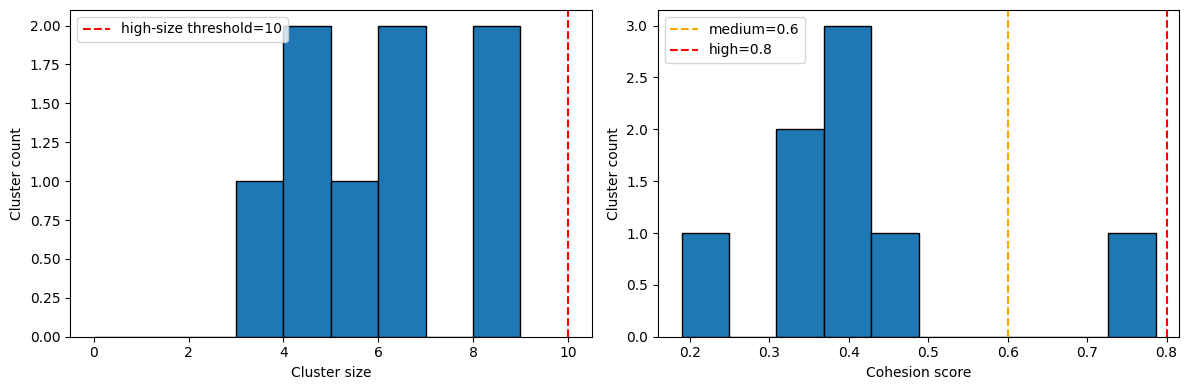

In [10]:
# Cohesion and size distribution for actual clusters we produced.
if clusters:
    rows = []
    for c in clusters:
        rows.append({"size": len(c.members), "cohesion": c.cohesion_score})
    df_c = pd.DataFrame(rows)
    print(df_c.describe())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(df_c["size"], bins=range(df_c["size"].max() + 2),
                 edgecolor="black")
    axes[0].axvline(10, color="red", linestyle="--", label="high-size threshold=10")
    axes[0].set_xlabel("Cluster size")
    axes[0].set_ylabel("Cluster count")
    axes[0].legend()
    axes[1].hist(df_c["cohesion"], bins=10, edgecolor="black")
    axes[1].axvline(0.6, color="orange", linestyle="--", label="medium=0.6")
    axes[1].axvline(0.8, color="red", linestyle="--", label="high=0.8")
    axes[1].set_xlabel("Cohesion score")
    axes[1].set_ylabel("Cluster count")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

## 7 · Model routing — complexity thresholds

Defaults on `model_routing.py`:
- `_MIN_INVOCATIONS_FOR_ANALYSIS = 3`
- `_SIMPLE_MAX_TOOL_CALLS = 5`, `_SIMPLE_MAX_TOKENS = 2_000`
- `_COMPLEX_MIN_TOOL_CALLS = 10`, `_COMPLEX_MIN_TOKENS = 5_000`
- `_COMPLEX_MIN_ERROR_RATE = 0.20`

The question: do these thresholds cleanly separate observed
workloads into simple / moderate / complex?

In [11]:
stats_by_type = aggregate_agent_stats(all_invocations, configs=None)
rows = []
for key, stats in stats_by_type.items():
    rows.append({
        "agent_type": stats.agent_type,
        "invocations": stats.invocation_count,
        "mean_tool_calls": stats.mean_tool_calls,
        "mean_tokens": stats.mean_tokens,
        "error_rate": stats.error_rate,
        "has_write_tools": stats.has_write_tools,
        "complexity": classify_complexity(stats),
    })
df_agents = pd.DataFrame(rows).sort_values("invocations", ascending=False)
df_agents

,agent_type,invocations,mean_tool_calls,mean_tokens,error_rate,has_write_tools,complexity
2,Explore,100,18.93,50740.55,0.32,True,complex
3,general-purpose,44,15.50,48743.75,0.35,True,complex
0,pm,33,9.67,42634.80,0.20,True,complex
6,unknown,32,19.89,43574.43,0.28,True,complex
1,architect,19,18.40,54951.40,0.34,False,complex
4,Plan,17,21.00,46771.41,0.26,True,complex
5,claude-code-guide,10,6.70,25651.10,0.32,False,complex


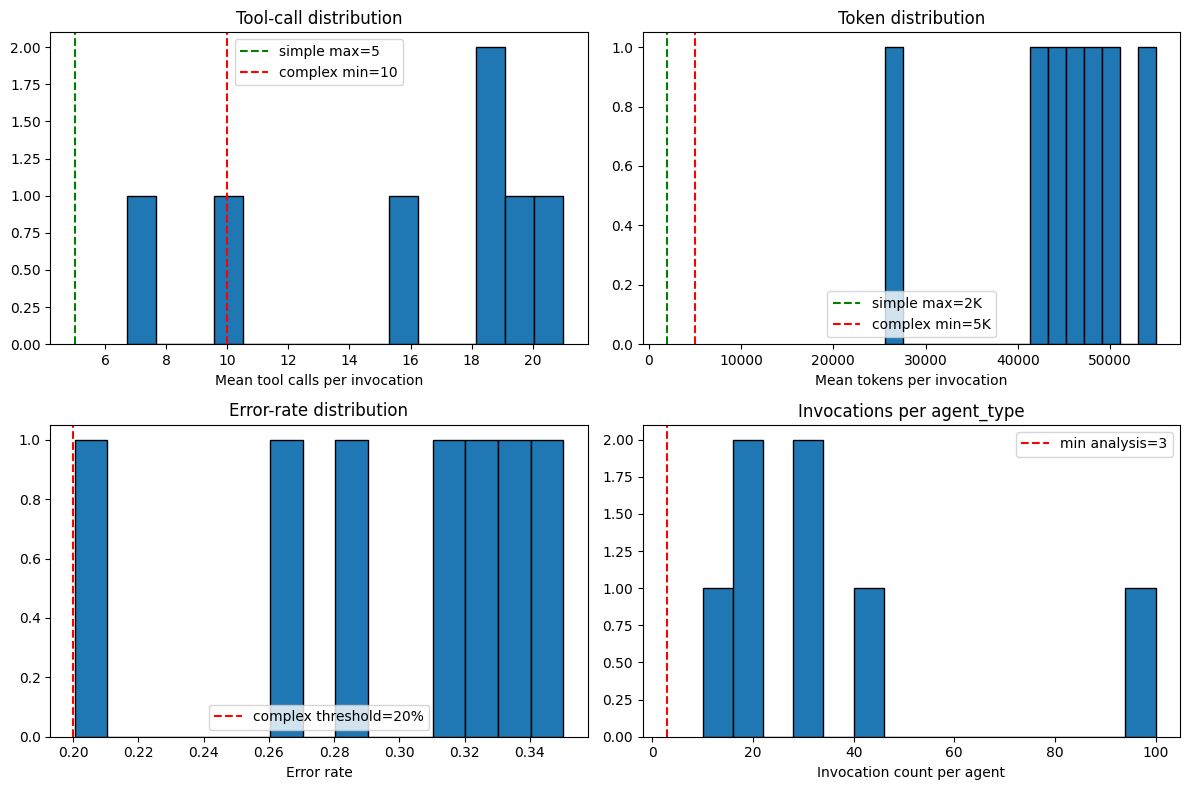

In [12]:
# Where do the current thresholds sit relative to the observed data?
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(df_agents["mean_tool_calls"], bins=15, edgecolor="black")
axes[0, 0].axvline(5, color="green", linestyle="--", label="simple max=5")
axes[0, 0].axvline(10, color="red", linestyle="--", label="complex min=10")
axes[0, 0].set_xlabel("Mean tool calls per invocation")
axes[0, 0].set_title("Tool-call distribution")
axes[0, 0].legend()

axes[0, 1].hist(df_agents["mean_tokens"], bins=15, edgecolor="black")
axes[0, 1].axvline(2000, color="green", linestyle="--", label="simple max=2K")
axes[0, 1].axvline(5000, color="red", linestyle="--", label="complex min=5K")
axes[0, 1].set_xlabel("Mean tokens per invocation")
axes[0, 1].set_title("Token distribution")
axes[0, 1].legend()

axes[1, 0].hist(df_agents["error_rate"], bins=15, edgecolor="black")
axes[1, 0].axvline(0.2, color="red", linestyle="--", label="complex threshold=20%")
axes[1, 0].set_xlabel("Error rate")
axes[1, 0].set_title("Error-rate distribution")
axes[1, 0].legend()

axes[1, 1].hist(df_agents["invocations"], bins=15, edgecolor="black")
axes[1, 1].axvline(3, color="red", linestyle="--", label="min analysis=3")
axes[1, 1].set_xlabel("Invocation count per agent")
axes[1, 1].set_title("Invocations per agent_type")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 8 · Before / after — signal counts with current vs proposed thresholds

Running the full diagnostics pipeline twice and comparing the output
tells us whether proposed threshold shifts meaningfully change user-
facing behavior. Counts only — qualitative inspection of a few signals
at the end.

In [13]:
from agentfluent.diagnostics.pipeline import run_diagnostics

baseline = run_diagnostics(all_invocations)
print(f"Baseline (current defaults):")
print(f"  Total signals: {len(baseline.signals)}")
sig_counts = Counter(s.signal_type.value for s in baseline.signals)
for stype, cnt in sig_counts.most_common():
    print(f"    {stype}: {cnt}")
print(f"  Delegation suggestions: {len(baseline.delegation_suggestions)}")
print(f"  Recommendations: {len(baseline.recommendations)}")

Baseline (current defaults):
  Total signals: 283
    retry_loop: 126
    tool_error_sequence: 100
    token_outlier: 21
    duration_outlier: 20
    permission_failure: 13
    model_mismatch: 2
    stuck_pattern: 1
  Delegation suggestions: 5
  Recommendations: 283


## 9 · Findings and chosen values

**Single-dataset caveat applies to everything below.** The
observations come from one contributor's `~/.claude/projects/` data —
7 projects, ~255 invocations, heavy toward substantive feature work.
A broader cross-contributor dataset would likely shift the picture.

**Data quality note:** this notebook was initially run against a
dataset silently truncated by parser bug #153 that dropped ~72% of
content blocks. Post-fix the dataset is ~2.6× larger and qualitatively
different — cluster counts, cohesion distributions, and signal rates
all changed substantially. Results below reflect the corrected state.

### Threshold-by-threshold observations

| Constant | Default | Decision | Notes |
|---|---|---|---|
| `MIN_TEXT_TOKENS` | 50 (was 20) | **raised** | Observed combined lengths on this dataset start ~100 tokens. Because these are agent-to-agent prompts, the original `20` anti-noise floor was well below the realistic distribution. Raised to `50` to preserve margin while still guarding against truncated/malformed input. Sweep range also widened to `[20, 30, 50, 75, 100, 150]` since testing below ~20 is meaningless for agent-generated text. |
| `LSA_COMPONENTS` | 50 | **flag for future review** | Sweep shows `n=30` reaches 91.2% variance on this dataset — the smallest swept value clearing the 90% target. Default of `50` auto-clips to `min(50, n-1)=43` on the 44-invocation corpus, so the effective value today is already 43 and KMeans still separates cleanly. Lowering to `30` would speed clustering at larger n without hurting quality on this data, but the optimal point depends on corpus diversity. Defer until multi-contributor data confirms. |
| `DEFAULT_MIN_CLUSTER_SIZE` | 5 | **keep** | Emits 5 clusters on my data at the default. Sweep goes 8→8→7→5→4→2→0 as threshold climbs from 2 to 10 — smooth curve, no sharp elbow. Default balances meaningful output vs noise. |
| `DEFAULT_MIN_SIMILARITY` | 0.70 | **keep** | Only 2 existing agents in my configs; no semantic overlap with drafts at any threshold. Dataset too small to calibrate dedup — requires configs with broader agent coverage. |
| `_SILHOUETTE_K_MAX` | 10 | **keep** | On n=44 the binding cap is `n // 5 = 8`; cap of 10 never engages. Correct default for larger datasets. |
| `_CONFIDENCE_HIGH_SIZE=10, HIGH_COHESION=0.8, MEDIUM_COHESION=0.6` | — | **flag for future lowering** | Observed cohesion on my clusters runs 0.19–0.79, mostly 0.33–0.47. Only 1 of 8 clusters (12.5%) reaches `MEDIUM_COHESION=0.6`; none reach `HIGH_COHESION=0.8`. Semantic review confirms the clusters ARE coherent (e.g., "hooks/claude", "tests/agentfluent/parser", "src/cli") — thresholds are calibrated above what real TF-IDF on agent delegations yields. Lowering to 0.3 medium / 0.5 high would reflect the actual signal but still needs multi-contributor validation. |
| `_MIN_INVOCATIONS_FOR_ANALYSIS` | 3 | **keep** | All 7 agent types on my data clear this threshold. Appropriate. |
| `_SIMPLE_MAX_TOOL_CALLS=5, _SIMPLE_MAX_TOKENS=2000` | — | **flag for future review** | Zero agent types on my data classify as "simple" — all 7 land on "complex" via tool-calls (6.7–21.0 mean, threshold=10), tokens (25K–55K mean, threshold=5K), or write tools. Thresholds may be set for a lighter workload than mine, or my workload is genuinely heavy. One dataset can't tell. |
| `_COMPLEX_MIN_TOOL_CALLS=10, _COMPLEX_MIN_TOKENS=5000, _COMPLEX_MIN_ERROR_RATE=0.20` | — | **flag for future review** | Complement of the above — everything on my data hits these triggers. The 5,000-token threshold especially looks low: 5K is medium-effort on my workload, not complex-outlier. |

### Summary: one constant raised, two flagged for future review

**Changed this PR:**
- **`MIN_TEXT_TOKENS` 20 → 50.** Anti-noise floor calibrated for
  human prompts, not the agent-to-agent corpus that actually flows
  through delegation. Observed distribution starts ~100 tokens, so
  `50` preserves full coverage with margin.

**Flagged for future review (no change yet):**
- **`LSA_COMPONENTS = 50`** could likely drop to `30`. On this data
  `n=30` captures 91.2% variance (the smallest swept value ≥ 90%
  target). Current default auto-clips to `min(50, n-1)=43` here, so
  the over-spec is invisible on small corpora; at larger n it would
  start to matter. Defer until multi-contributor data.
- **Confidence thresholds (0.6/0.8)** appear too high given the
  observed cluster-cohesion distribution (mean pairwise cosine among
  cluster members). Lowering to ~0.3/0.5 would activate the
  medium/high tiers that currently never fire. Defer until a second
  contributor dataset confirms this isn't a my-data artifact.
- **Simple/complex boundaries** put everything on my workload in
  "complex." Either the defaults are calibrated for a lighter
  workload, or mine is genuinely heavy-all-the-time. Indistinguishable
  from one contributor.

Both findings are safer to track as candidates for the next
calibration pass than to act on now.

### Re-running this notebook

```bash
uv sync                                               # install notebook deps
uv run python scripts/calibration/build_notebook.py   # regenerates + executes
```

Commit the updated `.ipynb` with its new outputs. Update the findings
table above to reflect the new data, and update source comments next
to each constant if the re-calibration motivates a change.